## 선형회귀란!

In [10]:
import numpy as np
from sklearn import linear_model  # scikit-learn 모듈을 가져온다

regr = linear_model.LinearRegression()

In [11]:
X = [[163], [179], [166], [169], [170]]
y = [54, 63, 57, 56, 58]
regr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# fit() 전후 타입 확인
print("fit() 호출 전:")
print(f"X의 타입: {type(X)}")
print(f"y의 타입: {type(y)}")
print(f"X = {X}")

regr.fit(X, y)  # 학습 수행

print("\nfit() 호출 후:")
print(f"X의 타입: {type(X)}")  # 여전히 list
print(f"y의 타입: {type(y)}")  # 여전히 list
print(f"X = {X}")  # 값도 그대로

print("\n결론: X, y는 여전히 리스트입니다!")
print("sklearn이 내부적으로만 numpy 배열로 변환해서 계산합니다.")

fit() 호출 전:
X의 타입: <class 'list'>
y의 타입: <class 'list'>
X = [[163], [179], [166], [169], [170]]

fit() 호출 후:
X의 타입: <class 'list'>
y의 타입: <class 'list'>
X = [[163], [179], [166], [169], [170]]

결론: X, y는 여전히 리스트입니다!
sklearn이 내부적으로만 numpy 배열로 변환해서 계산합니다.


In [13]:
coef=regr.coef_
coef
intercept=regr.intercept_
intercept
regr.predict([[178]])



array([62.20798898])

In [14]:
regr.score(X,y)

0.9222616348521422

## 데이터의 시각화와 차원 증가

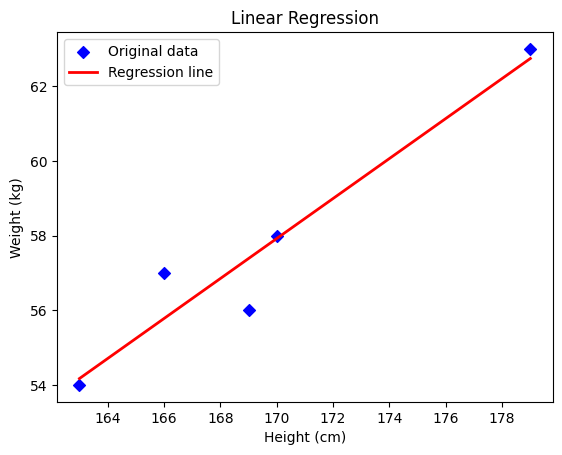

In [18]:
import numpy as np
from sklearn import linear_model  # scikit-learn 모듈을 가져온다
import matplotlib.pyplot as plt

regr = linear_model.LinearRegression()
X = [[163], [179], [166], [169], [170]]
y = [54, 63, 57, 56, 58]
regr.fit(X, y)

# 원본 데이터를 산점도로 표시
plt.scatter(X, y, color='blue', marker='D', label='Original data')

# 회귀선 그리기
X_test = np.linspace(163, 179, 100).reshape(-1, 1)
y_pred = regr.predict(X_test)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.title('Linear Regression')
plt.show()

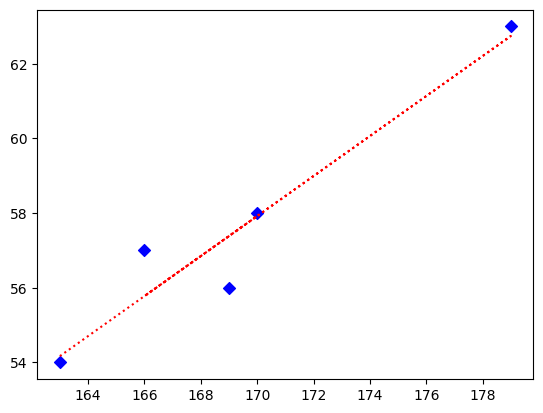

In [21]:
# 학습 데이터와 y 값을 산포도로 그린다.
plt.scatter(X, y, color='blue', marker='D')
# 학습 데이터를 입력으로 하여 예측값을 계산한다.

y_pred = regr.predict(X)
plt.plot(X, y_pred, 'r:') # 예측값을 이어주는 점선을 그려보자

In [22]:
unseen = [[167]]
result = regr.predict(unseen)
# unseen[0][0]로 167 값만 추출
print(f'동윤이의 키가 {unseen[0][0]}cm 이므로 몸무게는 {result[0].round(1)}kg으로 추정됨')

from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred)
print(f"데이터와 선형 회귀 직선의 R² 점수: {r2:.3f}")
print(f"설명력: {r2*100:.1f}% (1에 가까울수록 좋음)")

동윤이의 키가 167cm 이므로 몸무게는 56.3kg으로 추정됨
데이터와 선형 회귀 직선의 R² 점수: 0.922
설명력: 92.2% (1에 가까울수록 좋음)


남자, 여자로 구분 추가


In [26]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
# 남자는 0, 여자는 1
X = [[168, 0], [166, 0], [173, 0], [165, 0], [177, 0], [163, 0], \
     [178, 0], [172, 0], [163, 1], [162, 1], [171, 1], [162, 1], \
     [164, 1], [162, 1], [158, 1], [173, 1], ]    # 입력데이터를 2차원으로 만들어야 함
# y 값은 1차원 데이터
y = [65, 61, 68, 63, 68, 61, 76, 67, 55, 51, 59, 53, 61, 56, 44, 57]
regr.fit(X, y)         # 학습
print('계수 :', regr.coef_ )
print('절편 :', regr.intercept_)
print('점수 :', regr.score(X, y))
print('동윤이와 은지의 추정 몸무게 :', regr.predict([[167, 0], [167, 1]]))

계수 : [ 0.74803397 -7.23030041]
절편 : -61.22778389430634
점수 : 0.8425933302504423
동윤이와 은지의 추정 몸무게 : [63.69388959 56.46358918]


scikit-learn 명명 규칙
- **밑줄 없음**: 사용자가 설정하는 하이퍼파라미터
  - 예: `LinearRegression(fit_intercept=True)`
- **밑줄 있음 (`_`)**: `.fit()` 후 학습된 속성
  - 예: `coef_`, `intercept_`, `n_features_in_`
  
밑줄은 "이 값은 학습 후에만 존재한다"는 표시!

In [ ]:
# fit() 전에는 coef_가 존재하지 않음!
regr_test = linear_model.LinearRegression()

try:
    print(regr_test.coef_)  # 에러 발생!
except AttributeError as e:
    print(f"에러 발생: {e}")
    print("→ fit() 전에는 coef_가 없습니다!")

# fit() 후에만 coef_가 생성됨
X_test = [[1], [2], [3]]
y_test = [2, 4, 6]
regr_test.fit(X_test, y_test)
print(f"\nfit() 후 coef_: {regr_test.coef_}")
print(f"fit() 후 intercept_: {regr_test.intercept_}")
print(f"fit() 후 n_features_in_: {regr_test.n_features_in_}")  # 입력 특성 개수도 밑줄!

## 회귀모델의 오차 함수와 결정계수

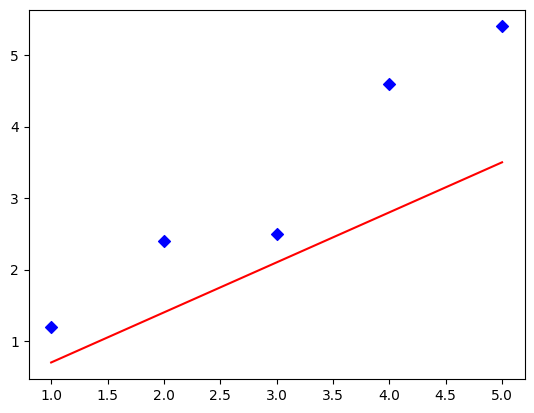

In [23]:
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5]) #
y = np.array([1.2, 2.4, 2.5, 4.6, 5.4]) # y 데이터

plt.scatter(x, y, color='blue', marker='D')
# y = 0.7x 추정 그래프를 빨간색 실선으로 그림
plt.plot(x, 0.7 * x, 'r-')

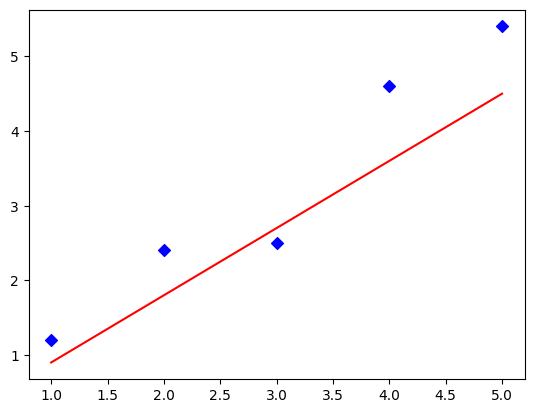

In [25]:
plt.scatter(x, y, color='blue', marker='D')
# y = 0.9x 추정 그래프를 빨간색 실선으로 그림
plt.plot(x, 0.9 * x, 'r-')

## 오차 함수의 구현과 파라미터 공간의 최적값

In [26]:
import numpy as np

y = np.array([1.2, 2.4, 2.5, 4.6, 5.4])
y_hat = np.array([1, 2, 3, 4, 5])
diff = (y_hat - y) ** 2     # y_hat과 y의 차이값의 제곱
e_mse = diff.sum() / len(y)
print('평균 제곱 오차 = ', e_mse)

평균 제곱 오차 =  0.19399999999999995


In [27]:
from sklearn.metrics import mean_squared_error

print('평균 제곱 오차 = ', mean_squared_error(y_hat, y))

평균 제곱 오차 =  0.19399999999999995


## 📌 두 가지 방법 비교

**방법 1: 경사 하강법 직접 구현** (위 코드)
- 학습 과정을 직접 코딩
- 내부 원리를 이해하기 좋음
- `w`, `b`를 반복문으로 업데이트

**방법 2: sklearn의 fit() 사용** (아래 코드)
- 단 한 줄로 학습: `regr.fit(X, y)`
- 내부적으로 최적화된 알고리즘 사용
- 실무에서는 이 방법 사용

두 방법 모두 같은 `w`, `b` 값을 찾습니다!

**방법 1: 경사 하강법 직접 구현**


In [28]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

w, b = 0, 0    # w, b 초기값을 0으로 두자
learning_rate, epoch = 0.005, 1000 # 학습률과 학습횟수(에폭)
n = len(X)  # 입력데이터 개수

for i in range(epoch):   # 학습 루프
    y_pred = w*X + b     # 현재 w, b를 이용한 작업 T
    error = y_pred - y   # 성능척도 P
    w = w - learning_rate * (error * X).sum() # 경험 E로 개선
    b = b - learning_rate * error.sum()

print('w = ', w.round(2), 'b =', b.round(2))

w =  0.63 b = -1.65


**방법2 간단히 아래와 같이 사용**

In [ ]:
from sklearn import linear_model
import numpy as np

# 위와 동일한 데이터
X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

regr = linear_model.LinearRegression()
X = X[:, np.newaxis] # 1차원 (5,)에서 2차원인 (5,1) 형태로 바꾼다

# 단 한 줄로 학습! (내부적으로 경사하강법 또는 정규방정식 사용)
regr.fit(X, y)

print(f'sklearn으로 학습한 결과:')
print(f'w = {regr.coef_.round(2)}, b = {regr.intercept_.round(2)}')
print(f'\n→ 직접 구현한 결과와 동일합니다!')

w = [0.63], b = -1.65


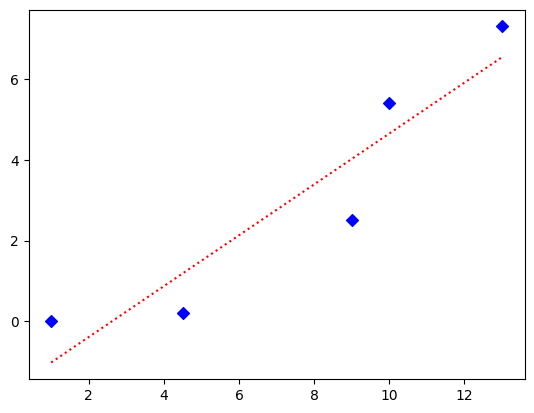

In [30]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])
plt.scatter(X, y, color='blue', marker='D')
# 계산으로 구한 w, b를 이용하여 선형 회귀 직선을 그리자
y_pred = 0.63 * X - 1.65
plt.plot(X, y_pred, 'r:')

### 📊 학습률(Learning Rate)의 영향

**학습률이 너무 작으면 (0.00001):**
- 📉 학습이 너무 느려서 epoch이 부족함
- 최적값 `w=0.63, b=-1.65`에 도달하지 못함
- 해결: epoch 증가 또는 학습률 증가

**학습률이 적절하면 (0.005):**
- ✅ 최적값에 정확히 도달
- `w=0.63, b=-1.65`

**학습률이 너무 크면 (1.0):**
- 💥 overshooting (최적값을 건너뜀)
- 값이 발산하거나 크게 진동
- 해결: 학습률 감소

In [ ]:
#학습률이 너무 작음
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])
regr_temp = linear_model.LinearRegression()

w, b = 0, 0    # w, b 초기값을 0으로 두자
learning_rate, epoch = 0.00001, 10000 # 학습률과 학습횟수(에폭)
n = len(X)  # 입력데이터 개수

for i in range(epoch):   # 학습 루프
    y_pred = w*X + b     # 현재 w, b를 이용한 작업 T
    error = y_pred - y   # 성능척도 P
    w = w - learning_rate * (error * X).sum() # 경험 E로 개선
    b = b - learning_rate * error.sum()

print(f'w = {w.round(2)}, b = {b.round(2)}')

w = 0.48, b = -0.15


In [35]:
# 학습률이 너무 큰 경우 (발산 예제)
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

w, b = 0, 0    # w, b 초기값을 0으로 두자
learning_rate, epoch = 1.0, 1000 # 학습률이 너무 큼!
n = len(X)  # 입력데이터 개수

# 처음 10번의 w, b 변화 추적
print("학습률이 너무 클 때의 w, b 변화:")
print(f"{'Epoch':<10} {'w':<15} {'b':<15}")
print("-" * 40)

for i in range(epoch):   # 학습 루프
    y_pred = w*X + b     # 현재 w, b를 이용한 작업 T
    error = y_pred - y   # 성능척도 P
    w = w - learning_rate * (error * X).sum() # 경험 E로 개선
    b = b - learning_rate * error.sum()
    
    # 처음 10번만 출력
    if i < 10:
        print(f"{i:<10} {w:<15.2f} {b:<15.2f}")
    
    # nan 또는 inf 체크
    if np.isnan(w) or np.isinf(w):
        print(f"\n⚠️ Epoch {i}에서 발산 발생!")
        break

print(f'\n최종 결과: w = {w}, b = {b}')
print("💥 학습률이 너무 크면 값이 폭발적으로 증가하여 발산합니다!")

학습률이 너무 클 때의 w, b 변화:
Epoch      w               b              
----------------------------------------
0          172.30          15.40          
1          -64199.27       -6507.45       
2          24013983.24     2433518.01     
3          -8982434049.17  -910258428.29  
4          3359880897937.35 340482310572.33
5          -1256763989107594.00 -127357462914924.56
6          470092771826396544.00 47638079443194488.00
7          -175838276747843108864.00 -17819031261262651392.00
8          65772335638186263838720.00 6665211503089167630336.00
9          -24602152701404310182821888.00 -2493123432444341879046144.00

⚠️ Epoch 119에서 발산 발생!

최종 결과: w = -inf, b = -2.6243803469629343e+307
💥 학습률이 너무 크면 값이 폭발적으로 증가하여 발산합니다!


In [36]:
# 학습률 비교: 너무 작음 vs 적절함 vs 너무 큼
import numpy as np

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

learning_rates = [0.00001, 0.005, 1.0]
labels = ['너무 작음 (0.00001)', '적절함 (0.005)', '너무 큼 (1.0)']
epoch = 1000

print(f"{'학습률':<25} {'w':<10} {'b':<10} {'상태'}")
print("-" * 60)

for lr, label in zip(learning_rates, labels):
    w, b = 0, 0
    for i in range(epoch):
        y_pred = w*X + b
        error = y_pred - y
        w = w - lr * (error * X).sum()
        b = b - lr * error.sum()
    
    # nan 또는 inf 체크
    if np.isnan(w) or np.isinf(w):
        status = "❌ 발산!"
        w_str, b_str = "발산", "발산"
    elif abs(w - 0.63) < 0.05 and abs(b - (-1.65)) < 0.5:
        status = "✅ 최적값 도달"
        w_str, b_str = f"{w:.2f}", f"{b:.2f}"
    else:
        status = "⚠️ 미수렴 (더 많은 epoch 필요)"
        w_str, b_str = f"{w:.2f}", f"{b:.2f}"
    
    print(f"{label:<25} {w_str:<10} {b_str:<10} {status}")

print(f"\n목표값: w=0.63, b=-1.65")

학습률                       w          b          상태
------------------------------------------------------------
너무 작음 (0.00001)           0.45       0.03       ⚠️ 미수렴 (더 많은 epoch 필요)
적절함 (0.005)               0.63       -1.65      ✅ 최적값 도달
너무 큼 (1.0)                발산         발산         ❌ 발산!

목표값: w=0.63, b=-1.65


/tmp/ipykernel_457448/4240089407.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * (error * X).sum()
